# Assignment 3: Linear Models

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

Linear in the parameters/coefficients. The predicted value is a weighted sum of the features. You can transform x however and the model is still linear as long as the coefficients just get multiplied and added up.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient on a dummy is the difference in the mean of y between that category and whichever category you dropped. If you drop the intercept instead, each coefficient is just the group mean directly.

3. Can linear regression be used for classification? Explain why, or why not.

Yes, a linear probability model. You just regress a 0/1 outcome on your features and treat the predictions as probabilities. The issue is predictions can go below 0 or above 1, but it's fine as an approximation.

4. What are signs that your linear model is over-fitting?

Big gap between training error and test error. R² is great on the training data but is bad on new data. Coefficients are huge or flip signs when you change the data slightly. Adding more variables helps training fit but makes test performance worse.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

If two features are highly correlated, when you x₁ on x₂ you get a really high R². That means x₂ already explains most of x₁, so they're carrying the same information. When you put both into the main regression, the model can't tell which one is actually doing the work, so the coefficients become unstable. This is why methods like two-stage least squares try to isolate the variation in a predictor that isn’t explained by other variables.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

Add polynomial terms (x², x³), interaction terms (x₁ * x₂), or transformations like log(x). The model is still linear in the coefficients even though the actual relationship between y and x is curved.

7. What is the interpretation of the slope coefficient in a linear regression?

It's the expected change in y for a one-unit increase in x, holding everything else constant.

8. Compare the train/test split and $k$-fold cross validation.

Train/test split just divides the data once, so your result depends on which observations end up where. K-fold splits it into k chunks, rotates which one is the test set, and averages the errors across all k rounds. K-fold gives a more stable estimate of how well the model generalizes.

9. How is the $k$ in $k$-fold cross validation typically selected?

Usually k=5 or k=10. Too few folds means your training set is way smaller than the full data, too many is expensive and noisy.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

In [36]:
bnb = pd.read_csv("data/Q1_clean.csv")
bnb.columns = bnb.columns.str.strip().str.replace(" ", "_")
bnb.head()

,Price,Review_Scores_Rating,Neighbourhood,Property_Type,Room_Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [37]:
avg_table = bnb.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']].mean()
print(avg_table)
print(f"\nMost expensive borough: {avg_table['Price'].idxmax()}")

                    Price  Review_Scores_Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750

Most expensive borough: Manhattan


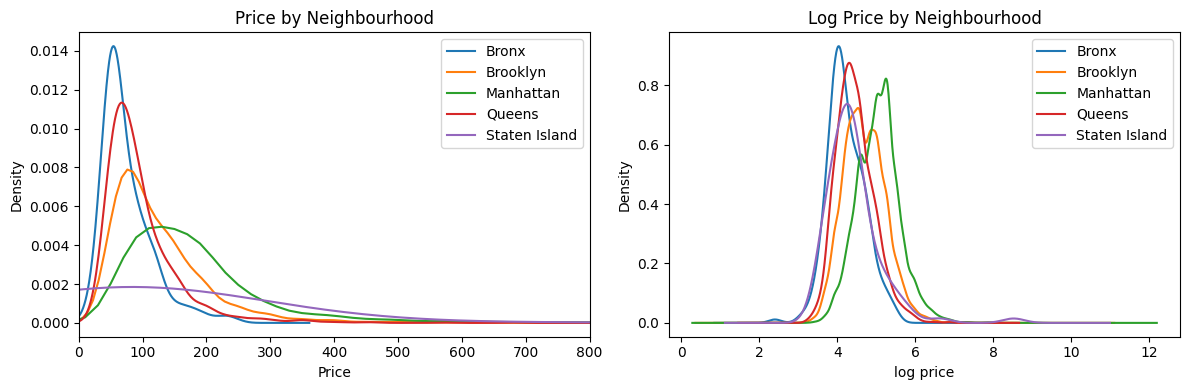

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, grp in bnb.groupby('Neighbourhood'):
    grp['Price'].plot.kde(ax=axes[0], label=name)
    np.log1p(grp['Price']).plot.kde(ax=axes[1], label=name)
axes[0].set_xlabel('Price')
axes[0].set_title('Price by Neighbourhood')
axes[0].legend()
axes[0].set_xlim(0, 800)
axes[1].set_xlabel('log price')
axes[1].set_title('Log Price by Neighbourhood')
axes[1].legend()
plt.tight_layout()
plt.show()

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [39]:
dummies = pd.get_dummies(bnb['Neighbourhood'], drop_first=True).astype(int)
X_hood = sm.add_constant(dummies)
model_hood = sm.OLS(bnb['Price'], X_hood).fit()
print(model_hood.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        12:56:35   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

I dropped the first category. So the intercept is the mean price for the baseline borough, and each dummy coefficient is how much different that borough's average is compared to the baseline. Intercept + coefficient = that borough's group mean, which matches the table

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

In [40]:
X_rating = sm.add_constant(bnb['Review_Scores_Rating'])
model_rating = sm.OLS(bnb['Price'], X_rating).fit()
print(model_rating.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        12:56:35   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

For every one-point increase in review score, nightly price goes up by 1.0208 dollars on average.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

In [41]:
X_both = sm.add_constant(pd.concat([dummies, bnb['Review_Scores_Rating']], axis=1))
model_both = sm.OLS(bnb['Price'], X_both).fit()
print(model_both.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        12:56:35   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

The rating slope changes because now we're controlling for neighbourhood, it's the effect of ratings within a given borough rather than across all of them. The neighbourhood coefficients shift too since they now represent price differences at the same rating level.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

In [42]:
hood_dummies_full = pd.get_dummies(bnb['Neighbourhood']).astype(int)
interactions = hood_dummies_full.multiply(bnb['Review_Scores_Rating'], axis=0)
interactions.columns = [f'{c}_x_Rating' for c in interactions.columns]

X_interact = sm.add_constant(interactions)
model_interact = sm.OLS(bnb['Price'], X_interact).fit()
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        12:56:35   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     55

The slopes are somewhat simiar but not identical. Manhattan probably has the biggest one since a higher rating there translates to a bigger price bump than in the other boroughs.

6. Use cross validation to evaluate the models from parts 2, 4, and 5.

In [43]:
from sklearn.model_selection import cross_val_score

y = bnb['Price'].values

#  neighbourhood dummies only
X_m2 = sm.add_constant(dummies).values
#  neighbourhood + rating
X_m4 = sm.add_constant(pd.concat([dummies, bnb['Review_Scores_Rating']], axis=1)).values
# neighbourhood-specific slopes
X_m5 = sm.add_constant(interactions).values

for label, X in [('Q2.2 hood only', X_m2), ('Q2.4 hood+rating', X_m4), ('Q2.5 hood-specific slopes', X_m5)]:
    scores = cross_val_score(LinearRegression(), X, y, cv=10, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{label:30s} CV RMSE: {rmse:.2f}")

Q2.2 hood only                 CV RMSE: 145.54
Q2.4 hood+rating               CV RMSE: 145.24
Q2.5 hood-specific slopes      CV RMSE: 145.15


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


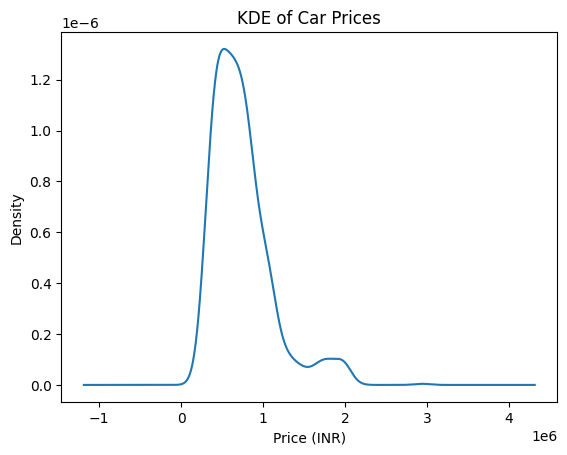

In [44]:
cars = pd.read_csv("data/cars_hw.csv", index_col=0)
print(cars['Price'].describe())
cars['Price'].plot.kde()
plt.xlabel('Price (INR)')
plt.title('KDE of Car Prices')
plt.show()

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


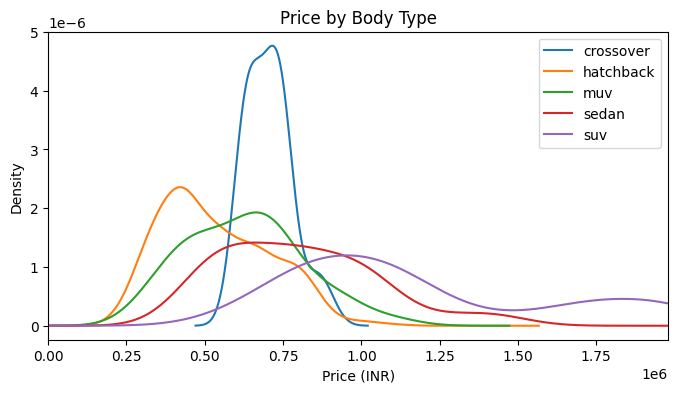

In [45]:
# Summarize by Body_Type
print(cars.groupby('Body_Type')['Price'].describe())

# Grouped KDE
fig, ax = plt.subplots(figsize=(8, 4))
for bt, grp in cars.groupby('Body_Type'):
    grp['Price'].plot.kde(ax=ax, label=bt)
ax.set_xlabel('Price (INR)')
ax.set_title('Price by Body Type')
ax.legend()
ax.set_xlim(0, cars['Price'].quantile(0.99))
plt.show()

SUVs are the most expensive on average and have the most spread. Hatchbacks are the cheapest and crossovers are the tightest.

2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

In [46]:
X_seats = sm.add_constant(cars['Seating_Capacity'])
model_seats = sm.OLS(cars['Price'], X_seats).fit()
print(model_seats.summary())
print(f"\nSlope: {model_seats.params['Seating_Capacity']:.0f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0245
Time:                        12:56:35   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [47]:
# Seating_Capacity one hot 
seat_dummies = pd.get_dummies(cars['Seating_Capacity'], prefix='seats', drop_first=True).astype(int)
X_seats_cat = sm.add_constant(seat_dummies)
model_seats_cat = sm.OLS(cars['Price'], X_seats_cat).fit()
print("Seating as categorical")
print(model_seats_cat.summary())

Seating as categorical
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000267
Time:                        12:56:35   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e

The continuous slope says each extra seat adds 59268 rupees on average. When you treat it as categorical and look at the dummy coefficients, you can tell if the jumps are actually equal or not. They are not equal in this scenario, 6 seaters are the most expensive, then adding seats makes the price decrease.

3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

degree 1: CV RMSE = 312,053
degree 2: CV RMSE = 312,083
degree 3: CV RMSE = 311,036
degree 4: CV RMSE = 310,202
degree 5: CV RMSE = 308,650
degree 6: CV RMSE = 308,802

Optimal degree: 5


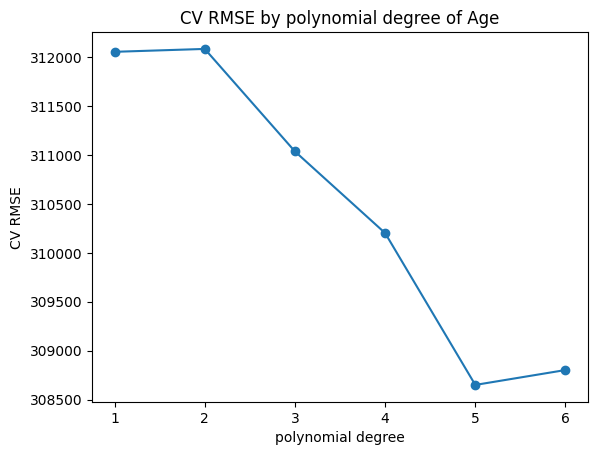

In [ ]:
cars['Age'] = cars['Make_Year'].max() - cars['Make_Year'] + 1

# 10-fold CV for polynomials of age deg 1 - 6
kf = KFold(n_splits=10, shuffle=True, random_state=42)
degrees = range(1, 7)
cv_rmses = []

for d in degrees:
    X_poly = np.column_stack([cars['Age'].values**p for p in range(1, d+1)])
    scores = cross_val_score(LinearRegression(), X_poly, cars['Price'].values, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    cv_rmses.append(rmse)
    print(f"degree {d}: CV RMSE = {rmse:,.0f}")

best_deg = list(degrees)[np.argmin(cv_rmses)]
print(f"\nOptimal degree: {best_deg}")

plt.plot(list(degrees), cv_rmses, marker='o')
plt.xlabel('polynomial degree')
plt.ylabel('CV RMSE')
plt.title('CV RMSE by polynomial degree of Age')
plt.show()

4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

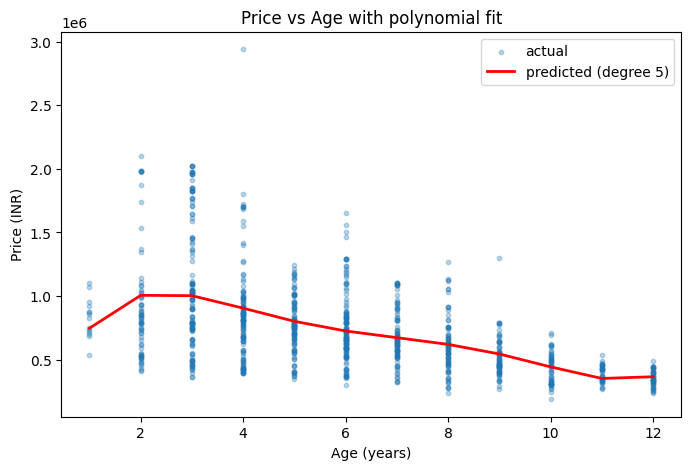

In [49]:
# Q3.4 — Plot Price vs Age, then predicted price vs Age
X_best = np.column_stack([cars['Age'].values**p for p in range(1, best_deg+1)])
lr = LinearRegression().fit(X_best, cars['Price'].values)

age_sorted = np.sort(cars['Age'].unique())
X_plot = np.column_stack([age_sorted**p for p in range(1, best_deg+1)])
y_pred_plot = lr.predict(X_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cars['Age'], cars['Price'], alpha=0.3, s=10, label='actual')
ax.plot(age_sorted, y_pred_plot, color='red', linewidth=2, label=f'predicted (degree {best_deg})')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Price (INR)')
ax.set_title('Price vs Age with polynomial fit')
ax.legend()
plt.show()

The model picks up the general pattern that newer cars cost more and price drops with age. It fits the central trend ok but there's a ton of variance at each age that it can't capture since we're ignoring body type, brand, mileage, etc.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

In [50]:
# Load heart data
heart = pd.read_csv("data/heart_hw.csv")
print(heart.shape)
heart.head()

(103, 4)


,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [51]:
# Q4.1 — Proportion surviving in each group and ATE
control_surv = heart[heart['transplant'] == 'control']['y'].mean()
treat_surv = heart[heart['transplant'] == 'treatment']['y'].mean()
ate = treat_surv - control_surv

print(f"Control survival rate: {control_surv:.4f}")
print(f"Treatment survival rate: {treat_surv:.4f}")
print(f"ATE (treatment - control): {ate:.4f}")

Control survival rate: 0.1176
Treatment survival rate: 0.3478
ATE (treatment - control): 0.2302


2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

In [52]:
# Q4.2 — Regress y on transplant dummy + constant
heart['transplant_d'] = (heart['transplant'] == 'treatment').astype(int)

X_transplant = sm.add_constant(heart['transplant_d'])
model_t = sm.OLS(heart['y'], X_transplant).fit()
print(model_t.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0133
Time:                        12:56:35   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1176      0.075      1.574   

The intercept is just the control group's survival rate and the transplant coefficient is the ATE. This makes sense since regressing a 0/1 outcome on a single dummy just gives the group means.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

In [53]:
# Q4.3 — Regress y on transplant + age
X_t_age = sm.add_constant(heart[['transplant_d', 'age']])
model_t_age = sm.OLS(heart['y'], X_t_age).fit()
print(model_t_age.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000357
Time:                        12:56:35   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7020      0.196      3.583   

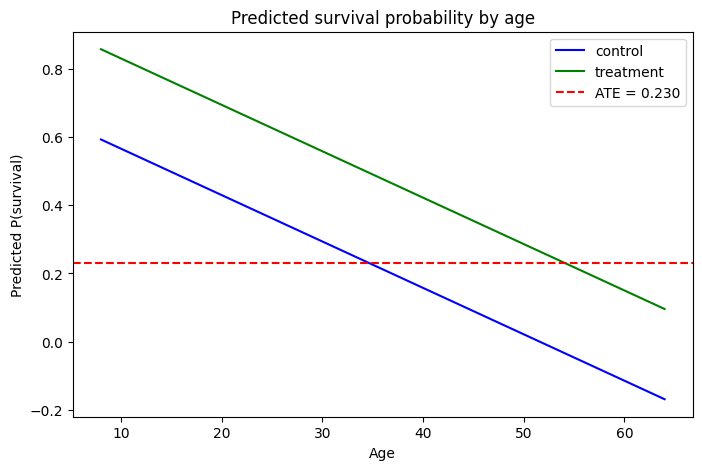

In [54]:
# Plot predicted probability of survival by age for each group
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

# Predictions for control (transplant_d=0) and treatment (transplant_d=1)
pred_control = model_t_age.params['const'] + model_t_age.params['age'] * age_range
pred_treat = pred_control + model_t_age.params['transplant_d']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_range, pred_control, label='control', color='blue')
ax.plot(age_range, pred_treat, label='treatment', color='green')
ax.axhline(y=ate, color='red', linestyle='--', label=f'ATE = {ate:.3f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted P(survival)')
ax.set_title('Predicted survival probability by age')
ax.legend()
plt.show()

The transplant coefficient changes when you add age because age is correlated with both who gets the transplant and who survives. The intercept is the predicted survival at age 0 for the control group which isn't meaningful. The age slope is how much survival probability drops per year. The ATE line overestimates the effect for older people and underestimates it for younger people since the model gives parallel lines but the ATE is just one flat average.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

In [55]:
# Q4.4 — Add interaction: transplant * age
heart['transplant_x_age'] = heart['transplant_d'] * heart['age']
X_interact_h = sm.add_constant(heart[['transplant_d', 'age', 'transplant_x_age']])
model_interact_h = sm.OLS(heart['y'], X_interact_h).fit()
print(model_interact_h.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000310
Time:                        12:56:35   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

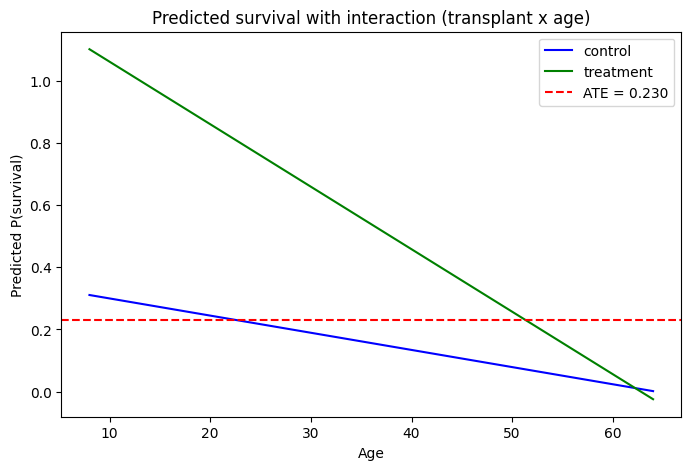

In [56]:
# Plot with interaction
pred_control_i = model_interact_h.params['const'] + model_interact_h.params['age'] * age_range
pred_treat_i = (model_interact_h.params['const'] + model_interact_h.params['transplant_d'] +
                (model_interact_h.params['age'] + model_interact_h.params['transplant_x_age']) * age_range)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(age_range, pred_control_i, label='control', color='blue')
ax.plot(age_range, pred_treat_i, label='treatment', color='green')
ax.axhline(y=ate, color='red', linestyle='--', label=f'ATE = {ate:.3f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted P(survival)')
ax.set_title('Predicted survival with interaction (transplant x age)')
ax.legend()
plt.show()

Now the two lines aren't parallel anymore. So the transplant effect depends on age. The lines cross at around 64, meaning the transplant helps at some ages but not others.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

In [57]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
y_h = heart['y'].values

# transplant only
X_h1 = sm.add_constant(heart[['transplant_d']]).values
# transplant + age
X_h2 = sm.add_constant(heart[['transplant_d', 'age']]).values
# transplant + age + interaction
X_h3 = sm.add_constant(heart[['transplant_d', 'age', 'transplant_x_age']]).values

for label, X in [('transplant only', X_h1), ('transplant + age', X_h2), ('transplant + age + interaction', X_h3)]:
    scores = cross_val_score(LinearRegression(), X, y_h, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{label:35s} CV RMSE: {rmse:.4f}")

transplant only                     CV RMSE: 0.4394
transplant + age                    CV RMSE: 0.4210
transplant + age + interaction      CV RMSE: 0.4185


6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

The treatment and control groups weren't randomly assigned, so the estimated effect is probably confounded,sicker or older people might have been more or less likely to get the transplant. The linear probability model can predict probabilities below 0 or above 1 which doesn't make sense. The sample is small so the estimates are noisy and you wouldn't want to make such important decisions off noisy coefficients. If the training data reflects historical biases in who got transplants, the model would just continue that. And we're only using age and transplant status and there's other factors that matter for outcomes like how healthy the person is otherwise.